<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1> Módulo 2: Construir Redes Neuronales Recurrentes en TensorFlow / Keras</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>

En este cuaderno de jupyter abordaremos la construcción, entrenamiento y evaluación de modelos basados en **Redes Neuronales Recurrentes (RNN)** utilizando la API de alto nivel de **TensorFlow y Keras**.

Desarrollaremos tres casos de estudio prácticos fundamentales:

1. **Clasificación de Sentimientos en Texto (Dataset IMDB)**:
   - Uso de capas de incrustación de palabras (`layers.Embedding`).
   - Procesamiento bidireccional de secuencias de texto con `layers.Bidirectional(layers.LSTM(...))`.
   - Manejo de longitudes variables de secuencia mediante relleno y truncamiento (*Padding*).

2. **Predicción de Series Temporales (Google Stock Price)**:
   - Construcción de tensores de series temporales tridimensionales `(batch_size, timesteps, features)` mediante el esquema de **ventana deslizante (*Sliding Window*)**.
   - Apilamiento de múltiples capas recurrentes (*Stacked LSTMs*) con `return_sequences=True`.
   - Regularización con `layers.Dropout` y normalización de variables con `MinMaxScaler`.

3. **Generación Autorregresiva de Texto a Nivel de Caracteres (*Char-Level Language Model*)**:
   - Modelado probabilístico secuencial sobre el corpus de obras de Shakespeare.
   - Creación de pipelines eficientes con `tf.data.Dataset`.
   - Algoritmo de muestreo estocástico con **Temperatura ($T$)** para balancear coherencia vs. creatividad.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb

# Fijar semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"Versión de TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs disponibles: {len(gpus)} -> {gpus if gpus else 'Ejecutando en CPU'}")

Versión de TensorFlow: 2.21.0
GPUs disponibles: 0 -> Ejecutando en CPU


# 1. Clasificación de Sentimientos con el Dataset IMDB

El dataset de **IMDB** es un punto de referencia estándar en Procesamiento de Lenguaje Natural (PLN). Contiene **50,000 reseñas de películas** altamente polarizadas (25,000 para entrenamiento y 25,000 para prueba), etiquetadas como:
* **`1`**: Sentimiento positivo 
* **`0`**: Sentimiento negativo 

### Flujo de trabajo:
1. **Selección del vocabulario**: Conservamos las $N$ palabras más frecuentes (por ejemplo, las 20,000 más comunes).
2. **Homogeneización (*Padding*)**: Fijamos una longitud máxima de secuencia ($L = 150$ palabras).
3. **Capa Embedding**: Proyecta cada índice entero a un espacio vectorial continuo denso $\mathbb{R}^{d}$.
4. **Capa Recurrente LSTM Bidireccional**: Captura dependencias contextuales hacia adelante y hacia atrás.
5. **Capa Densa Sigmoide**: Produce la probabilidad de sentimiento positivo.

In [2]:
# Parámetros del dataset
vocab_size = 20000  # Consideramos las 20,000 palabras más frecuentes
max_len = 150       # Longitud fija de las secuencias de texto (número de palabras por reseña)

print("Cargando el dataset de IMDB...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba:        {len(X_test)}")
print(f"Ejemplo de reseña codificada (primeras 15 palabras): {X_train[0][:15]}")
print(f"Etiqueta de la primera reseña: {y_train[0]} ({'Positiva' if y_train[0] == 1 else 'Negativa'})")

Cargando el dataset de IMDB...
Muestras de entrenamiento: 25000
Muestras de prueba:        25000
Ejemplo de reseña codificada (primeras 15 palabras): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]
Etiqueta de la primera reseña: 1 (Positiva)


### Exploración y Decodificación de Texto

El dataset de Keras ya viene pre-tokenizado como secuencias de identificadores enteros. Podemos utilizar el diccionario de mapeo `imdb.get_word_index()` para reconstruir y visualizar las reseñas en lenguaje humano:

In [3]:
word_index = imdb.get_word_index()

# Los primeros índices están reservados en Keras:
# 0: <PAD>, 1: <START>, 2: <UNK>, 3: <UNUSED>
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_text):
    return " ".join([reverse_word_index.get(i, "?") for i in encoded_text])

print("Texto decodificado de la primera reseña:")
print("-" * 70)
print(decode_review(X_train[0][:60]) + " ...")
print("-" * 70)

Texto decodificado de la primera reseña:
----------------------------------------------------------------------
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film ...
----------------------------------------------------------------------


In [4]:
reverse_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

### Homogeneización de Secuencias (*Padding y Truncating*)

Dado que las reseñas tienen longitudes diferentes y las redes neuronales procesan tensores en lotes (*batches*) de forma matricial fija, debemos estandarizar todas las secuencias a una longitud común de `max_len = 150`:
* Si la reseña es más corta que 150 palabras, se rellena con ceros (`<PAD>`).
* Si la reseña es más larga, se trunca a 150 palabras.

In [5]:
# Aplicamos pad_sequences
X_train_padded = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test_padded = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

print(f"Forma de X_train_padded: {X_train_padded.shape}")
print(f"Forma de X_test_padded:  {X_test_padded.shape}")
print(f"Primer vector procesado:\n{X_train_padded[0][:25]} ...")

Forma de X_train_padded: (25000, 150)
Forma de X_test_padded:  (25000, 150)
Primer vector procesado:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50] ...


### Construcción de la Red Neuronal Recurrente con LSTM Bidireccional

Diseñaremos una arquitectura robusta para clasificación binaria de texto:
1. `layers.Embedding(input_dim=vocab_size, output_dim=128)`: Aprende una representación vectorial continua para cada palabra.
2. `layers.SpatialDropout1D(0.2)`: Regulariza omitiendo columnas completas de la matriz de incrustación para evitar sobreajuste en palabras específicas.
3. `layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0))`: Procesa la secuencia en ambas direcciones temporales.
4. `layers.Dense(32, activation='relu')`: Capa completamente conectada para refinar la extracción de patrones.
5. `layers.Dropout(0.3)`: Dropout estándar para generalización.
6. `layers.Dense(1, activation='sigmoid')`: Capa de salida con activación sigmoide para predecir la probabilidad $P(y = 1 \mid \text{texto})$.

In [6]:
embed_dim = 128

imdb_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim = embed_dim),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')], 
                             name = 'IMDB_Bidirectional_LSTM')

imdb_model.summary()

Model: "IMDB_Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 150, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 150, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,662,977 (10.16 MB)

 Trainable params: 2,662,977 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
imdb_model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001),
                  loss='binary_crossentropy', 
                  metrics = ['accuracy'])
# Entrenamos por 4 épocas con un subconjunto de validación del 20%
batch_size = 128
epochs = 4

history_imdb = imdb_model.fit(X_train_padded, y_train, validation_split = 0.2, epochs = epochs, batch_size = batch_size, verbose=1)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.7237 - loss: 0.5196 - val_accuracy: 0.8426 - val_loss: 0.3643
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.8878 - loss: 0.2887 - val_accuracy: 0.8398 - val_loss: 0.3898
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.9186 - loss: 0.2227 - val_accuracy: 0.8448 - val_loss: 0.3708
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 196ms/step - accuracy: 0.9387 - loss: 0.1718 - val_accuracy: 0.8392 - val_loss: 0.4222


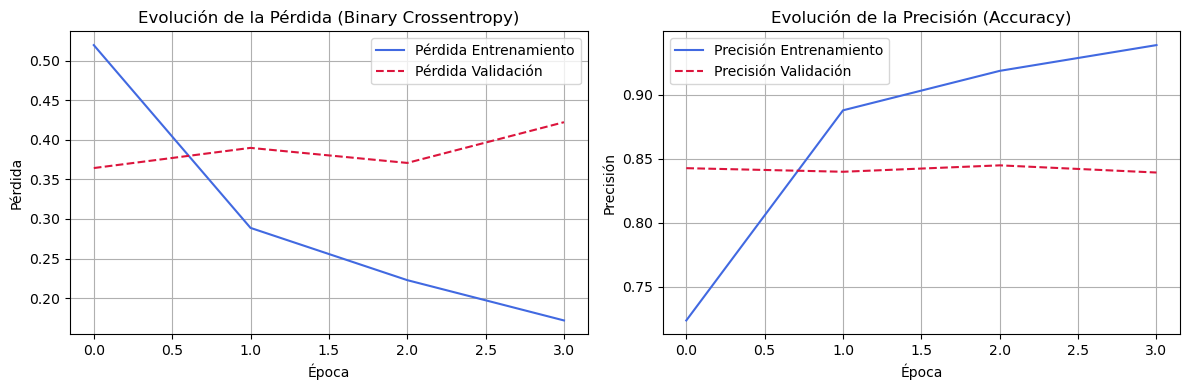

In [9]:
# Visualización de curvas de aprendizaje
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_imdb.history['loss'], label='Pérdida Entrenamiento', color='royalblue')
plt.plot(history_imdb.history['val_loss'], label='Pérdida Validación', color='crimson', linestyle='--')
plt.title('Evolución de la Pérdida (Binary Crossentropy)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_imdb.history['accuracy'], label='Precisión Entrenamiento', color='royalblue')
plt.plot(history_imdb.history['val_accuracy'], label='Precisión Validación', color='crimson', linestyle='--')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluación sobre el Conjunto de Prueba e Inferencia con Nuevas Reseñas

Evaluamos el modelo final sobre las 25,000 reseñas del conjunto de prueba e implementamos una función `predict_sentiment` para clasificar cualquier texto arbitrario ingresado en inglés:

In [10]:
# 1. Evaluación en test set
test_loss, test_acc = imdb_model.evaluate(X_test_padded, y_test, batch_size=128, verbose=0)
print(f" Rendimiento en Test Set:")
print(f"   - Pérdida (Loss):    {test_loss:.4f}")
print(f"   - Exactitud (Acc):   {test_acc * 100:.2f}%\n")

# 2. Función de inferencia para frases arbitrarias
def predict_sentiment(text, model, maxlen=max_len):
    # Tokenización simple en minúsculas
    tokens = text.lower().replace('.', ' ').replace(',', ' ').split()
    # Mapeo a índices del vocabulario IMDB
    encoded = [word_index.get(token, 2) + 3 for token in tokens if word_index.get(token, 2) + 3 < vocab_size]
    # Padding
    padded = keras.preprocessing.sequence.pad_sequences([encoded], maxlen=maxlen, padding='post', truncating='post')
    
    # Inferencia
    prob = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positivo" if prob >= 0.5 else "Negativo"
    
    print(f"Reseña: \"{text}\"")
    print(f"Probabilidad Positiva: {prob:.4f} -> Predicción: {sentiment}\n")

# Pruebas con frases de ejemplo
predict_sentiment("This movie was absolutely wonderful, fantastic acting and brilliant plot!", imdb_model)
predict_sentiment("Terrible film, completely waste of time, boring and poorly directed.", imdb_model)
predict_sentiment("The story was okay, some good moments but quite predictable overall.", imdb_model)

 Rendimiento en Test Set:
   - Pérdida (Loss):    0.4744
   - Exactitud (Acc):   81.33%

Reseña: "This movie was absolutely wonderful, fantastic acting and brilliant plot!"
Probabilidad Positiva: 0.9937 -> Predicción: Positivo

Reseña: "Terrible film, completely waste of time, boring and poorly directed."
Probabilidad Positiva: 0.0060 -> Predicción: Negativo

Reseña: "The story was okay, some good moments but quite predictable overall."
Probabilidad Positiva: 0.6577 -> Predicción: Positivo



# 2. Predicción de Series Temporales Financieras con LSTM Apiladas (Google Stock Price)

En este problema de **regresión secuencial**, el objetivo es pronosticar el precio de apertura (*Open*) de las acciones de Google para el día $t$ utilizando como entrada la ventana temporal de los 60 días de negociación previos ($t-60$ a $t-1$).

### Metodología:
1. **Escalamiento Min-Max**: La función de activación $\tanh$ en las celdas LSTM es altamente sensible a la escala de las entradas. Normalizamos los datos a $[0, 1]$.
2. **Esquema de Ventana Deslizante (*Sliding Window*)**: Transformamos una serie 1D en un tensor tridimensional con forma `(muestras, 60, 1)`.
3. **Red LSTM Profunda (Stacked LSTM)**: Apilamos 4 capas `LSTM` con `Dropout(0.2)` intermedio. Para apilar capas recurrentes, las primeras deben tener activado `return_sequences=True`.
4. **Inversión de Escala y Evaluación**: Revertimos la transformación con `MinMaxScaler.inverse_transform` y contrastamos visualmente con los precios reales del conjunto de test (`Google_Stock_Price_Test.csv`).

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Carga de datos de entrenamiento comprobando rutas relativas
train_csv_path = 'Data/Google_Stock_Price_Train.csv'
dataset_train = pd.read_csv(train_csv_path)

print(f"Dimensiones del dataset de entrenamiento: {dataset_train.shape}")
display(dataset_train.head())

# Extraemos la serie de la columna 'Open'
training_set = dataset_train[['Open']].values

# Normalización MinMax al rango [0, 1]
scaler = MinMaxScaler(feature_range= (0,1))
training_set_scaled = scaler.fit_transform(training_set)
training_set_scaled

Dimensiones del dataset de entrenamiento: (1258, 6)


,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]], shape=(1258, 1))

In [17]:
# Parámetros de la ventana temporal
TIMESTEPS = 60

X_train_stock = []
y_train_stock = []

# Construcción de ventanas: desde el índice 60 hasta el final
for i in range(TIMESTEPS, len(training_set_scaled)):
    X_train_stock.append(training_set_scaled[i-TIMESTEPS:i, 0])
    y_train_stock.append(training_set_scaled[i, 0])

X_train_stock = np.array(X_train_stock)
y_train_stock = np.array(y_train_stock)
    
# Redimensionar a formato 3D requerido por Keras: (muestras, timesteps, features)
X_train_stock = np.reshape(X_train_stock, (X_train_stock.shape[0], X_train_stock.shape[1], 1))


In [18]:
X_train_stock.shape

(1198, 60, 1)

### Arquitectura del Modelo Regresor (Stacked LSTM)

Construimos un modelo `Sequential` con 4 capas LSTM profundas:
* **Capas 1, 2 y 3**: `LSTM(units=50, return_sequences=True)` para que cada capa pase su secuencia completa de salidas a la siguiente.
* **Capa 4**: `LSTM(units=50, return_sequences=False)` para obtener únicamente el vector final de características ocultas.
* **Regularización**: `Dropout(0.2)` entre cada bloque LSTM para mitigar el sobreajuste.
* **Capa Densa Final**: `Dense(units=1)` con activación lineal para predecir el valor escalar continuo.

In [21]:
# Arquitectura
stock_regresor = keras.Sequential([
    layers.Input(shape=(X_train_stock.shape[1],1)),
    #Capa 1 LSTM
    layers.LSTM(units=50, return_sequences = True),
    layers.Dropout(0.2),
    #Capa 2 LSTM
    layers.LSTM(units=50, return_sequences = True),
    layers.Dropout(0.2),
    #Capa 3 LSTM
    layers.LSTM(units=50, return_sequences = True),
    layers.Dropout(0.2),
    #Capa 4 LSTM
    layers.LSTM(units=50, return_sequences = False),
    layers.Dropout(0.2),

    #Capa de salida lineal por que eso es un modelo de regresion
    layers.Dense(units=1)
], name='Google_stocke_LSTM')
stock_regresor.summary()


Model: "Google_stocke_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
stock_regresor.compile(optimizer='adam', loss= 'mean_squared_error')


In [25]:
# Entrenamiento del modelo
epochs_stock = 25
batch_size_stock = 32

history_stock = stock_regresor.fit(X_train_stock, y_train_stock, epochs = epochs_stock, batch_size = batch_size_stock, verbose = 1)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0030
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0032
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0036
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0031
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0030
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0028
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0027
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0027
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0027
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0028
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0026
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0026
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0028
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0027
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0029
Epoc

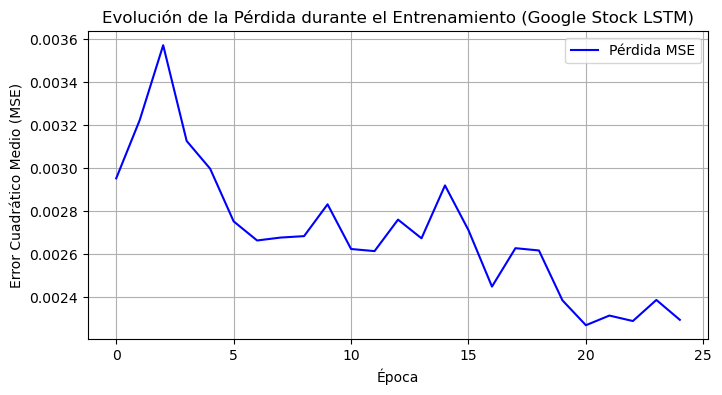

In [26]:
# Gráfica de la función de pérdida durante el entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(history_stock.history['loss'], color='blue', label='Pérdida MSE')
plt.title('Evolución de la Pérdida durante el Entrenamiento (Google Stock LSTM)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True)
plt.legend()
plt.show()

### Evaluación sobre el Conjunto de Prueba (`Google_Stock_Price_Test.csv`)

Para predecir el primer día del conjunto de prueba (enero 2017), necesitamos los **60 días inmediatamente anteriores**. Por ello:
1. Concatenamos la columna `Open` del conjunto de entrenamiento y el conjunto de prueba.
2. Tomamos el rango necesario desde `len(total) - len(test) - 60`.
3. Aplicamos `scaler.transform` (usando el escalador ajustado con los datos de train).
4. Generamos las ventanas de entrada para el conjunto de prueba.
5. Invertimos la escala de las predicciones con `scaler.inverse_transform` y graficamos.

In [27]:
# 1. Carga del conjunto de prueba
test_csv_path = 'Data/Google_Stock_Price_Test.csv' 
dataset_test = pd.read_csv(test_csv_path)
real_stock_price = dataset_test[['Open']].values

In [37]:
dataset_test

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"
5,1/10/2017,807.86,809.13,803.51,804.79,"1,176,800"
6,1/11/2017,805.00,808.15,801.37,807.91,"1,065,900"
7,1/12/2017,807.14,807.39,799.17,806.36,"1,353,100"
8,1/13/2017,807.48,811.22,806.69,807.88,"1,099,200"
9,1/17/2017,807.08,807.14,800.37,804.61,"1,362,100"


In [30]:
# 2. Concatenación y obtención de las entradas
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - TIMESTEPS:].values
inputs = inputs.reshape(-1,1)

In [31]:
inputs

array([[779.  ],
       [779.66],
       [777.71],
       [786.66],
       [783.76],
       [781.22],
       [781.65],
       [779.8 ],
       [787.85],
       [798.24],
       [803.3 ],
       [795.  ],
       [804.9 ],
       [816.68],
       [806.34],
       [801.  ],
       [808.35],
       [795.47],
       [782.89],
       [778.2 ],
       [767.25],
       [750.66],
       [774.5 ],
       [783.4 ],
       [779.94],
       [791.17],
       [756.54],
       [755.6 ],
       [746.97],
       [755.2 ],
       [766.92],
       [771.37],
       [762.61],
       [772.63],
       [767.73],
       [764.26],
       [760.  ],
       [771.53],
       [770.07],
       [757.44],
       [744.59],
       [757.71],
       [764.73],
       [761.  ],
       [772.48],
       [780.  ],
       [785.04],
       [793.9 ],
       [797.4 ],
       [797.34],
       [800.4 ],
       [790.22],
       [796.76],
       [795.84],
       [792.36],
       [790.9 ],
       [790.68],
       [793.7 ],
       [783.33

In [32]:
# 3. Escalamiento usando el scaler ya entrenado
inputs_scaled = scaler.transform(inputs)
inputs_scaled

array([[0.9299055 ],
       [0.93113327],
       [0.92750577],
       [0.94415507],
       [0.93876032],
       [0.93403527],
       [0.93483518],
       [0.9313937 ],
       [0.94636878],
       [0.96569685],
       [0.97510976],
       [0.95966962],
       [0.97808617],
       [1.        ],
       [0.98076494],
       [0.97083116],
       [0.98450406],
       [0.96054394],
       [0.9371419 ],
       [0.92841729],
       [0.90804747],
       [0.8771858 ],
       [0.92153434],
       [0.93809063],
       [0.93165414],
       [0.95254483],
       [0.88812412],
       [0.88637547],
       [0.87032145],
       [0.88563137],
       [0.90743359],
       [0.91571173],
       [0.89941588],
       [0.91805566],
       [0.9089404 ],
       [0.9024853 ],
       [0.89456061],
       [0.91600938],
       [0.9132934 ],
       [0.88979835],
       [0.86589404],
       [0.89030062],
       [0.90335962],
       [0.89642086],
       [0.91777662],
       [0.93176576],
       [0.94114145],
       [0.957

In [33]:
# 4. Construcción de ventanas de prueba
X_test_stock = []
for i in range(TIMESTEPS, len(inputs_scaled)):
    X_test_stock.append(inputs_scaled[i - TIMESTEPS : i, 0])
X_test_stock = np.array(X_test_stock)
X_test_stock.shape

(20, 60)

In [34]:
X_test_stock = np.reshape(X_test_stock, (X_test_stock.shape[0], X_test_stock.shape[1], 1))
X_test_stock.shape

(20, 60, 1)

In [35]:
# 5. Inferencia y desescalamiento
predicted_stock_price_scaled = stock_regresor.predict(X_test_stock)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price_scaled)
predicted_stock_price

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step


array([[787.9851 ],
       [786.1072 ],
       [784.283  ],
       [782.7653 ],
       [781.95544],
       [782.32404],
       [783.9636 ],
       [786.5222 ],
       [789.5788 ],
       [792.7167 ],
       [795.5853 ],
       [797.92114],
       [799.5906 ],
       [800.65295],
       [801.23883],
       [801.94775],
       [803.3143 ],
       [805.70667],
       [808.9305 ],
       [811.9336 ]], dtype=float32)

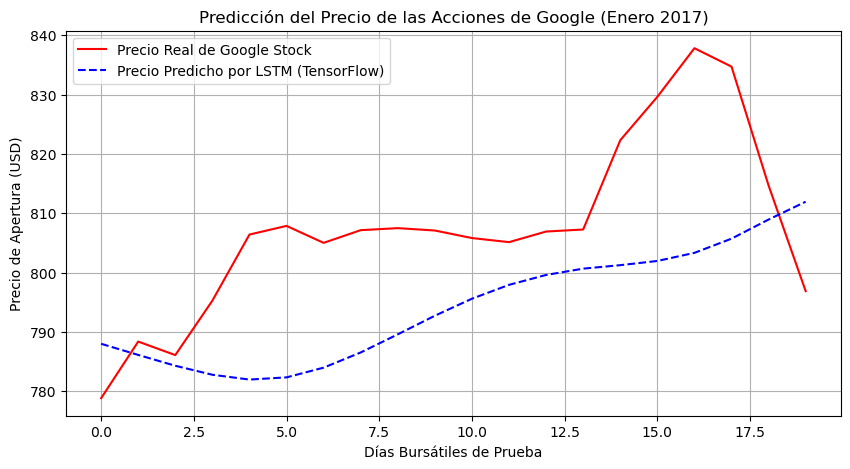

In [36]:
# Visualización comparativa
plt.figure(figsize=(10, 5))
plt.plot(real_stock_price, color='red', label='Precio Real de Google Stock')
plt.plot(predicted_stock_price, color='blue', linestyle='--', label='Precio Predicho por LSTM (TensorFlow)')
plt.title('Predicción del Precio de las Acciones de Google (Enero 2017)')
plt.xlabel('Días Bursátiles de Prueba')
plt.ylabel('Precio de Apertura (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Generación Autorregresiva de Texto a Nivel de Caracteres con LSTM

Un **Modelo de Lenguaje a Nivel de Caracteres (*Character-Level Language Model*)** aprende a predecir el siguiente carácter $c_{t+1}$ condicionada a la secuencia de caracteres observados anteriormente:

$$P(c_{t+1} \mid c_1, c_2, \dots, c_t)$$

<img src="Figures/63.png" alt="Character-level model" style="display: block; margin: 0 auto;" width="500">

### Flujo de Implementación con TensorFlow:
1. **Descarga del Corpus**: Descargamos el texto de las obras de Shakespeare.
2. **Vocabulario y Mapeos**: Mapeamos cada carácter único a un entero (`char2idx`) y viceversa (`idx2char`).
3. **Pipeline con `tf.data.Dataset`**: Dividimos el texto en secuencias de longitud fija `seq_length=100`, donde la entrada es `chunk[:-1]` y el objetivo desplazado es `chunk[1:]`.
4. **Arquitectura LSTM Generativa**: Capa `Embedding`, capas `LSTM` con `return_sequences=True` y capa `Dense(vocab_size)`.
5. **Muestreo con Temperatura ($T$)**: La temperatura controla la dispersión de la distribución de probabilidad durante la generación:
   $$\text{logits}_{\text{ajustados}} = \frac{z_i}{T}$$
   - **$T$ baja (ej. $0.2$)**: Texto muy conservador, repetitivo y gramaticalmente rígido.
   - **$T$ media (ej. $0.7$)**: Buen balance entre fluidez, gramática y creatividad.
   - **$T$ alta (ej. $1.2$)**: Mayor diversidad léxica pero con mayor probabilidad de inventar palabras erróneas.

In [38]:
# 1. Descarga del corpus de texto
shakespeare_path = tf.keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

text = open(shakespeare_path, 'rb').read().decode(encoding='utf-8')
print(f"Longitud total del texto: {len(text):,} caracteres")

# 2. Vocabulario de caracteres únicos
vocab_char = sorted(set(text))
vocab_char_size = len(vocab_char)
print(f"Número de caracteres únicos (vocabulario): {vocab_char_size}")

# Mapeos de caracteres a índices y viceversa
char2idx = {char: idx for idx, char in enumerate(vocab_char)}
idx2char = np.array(vocab_char)

# Representación numérica de todo el texto
text_as_int = np.array([char2idx[c] for c in text])

print("\nPrimeros 100 caracteres del corpus:")
print("-" * 50)
print(text[:100])
print("-" * 50)

Longitud total del texto: 1,115,394 caracteres
Número de caracteres únicos (vocabulario): 65

Primeros 100 caracteres del corpus:
--------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
--------------------------------------------------


In [40]:
# Longitud máxima de secuencia por muestra y tamaño de lote
SEQ_LEN = 100
BATCH_SIZE = 64
BUFFER_SIZE = 10000

# Función para dividir secuencias en (entrada, objetivo_desplazado_un_caracter)
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text


In [41]:
# Creación del tf.data.Dataset
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(SEQ_LEN + 1, drop_remainder = True)
dataset_gen = sequences.map(split_input_target)
dataset_gen = dataset_gen.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder = True).prefetch(tf.data.AUTOTUNE)
dataset_gen.element_spec

(TensorSpec(shape=(64, 100), dtype=tf.int64, name=None),
 TensorSpec(shape=(64, 100), dtype=tf.int64, name=None))

In [42]:
# Verificamos un ejemplo de entrada y salida
for input_example, target_example in dataset_gen.take(1):
    print("\nEjemplo Entrada (Input):")
    print(repr("".join(idx2char[input_example[0].numpy()[:40]])))
    print("Ejemplo Salida Esperada (Target):")
    print(repr("".join(idx2char[target_example[0].numpy()[:40]])))


Ejemplo Entrada (Input):
' them fight that will,\nFor I have murder'
Ejemplo Salida Esperada (Target):
'them fight that will,\nFor I have murdere'


In [43]:
def build_text_generation_model(vocab_size, embedding_dim=256, rnn_units=512):
    model = keras.Sequential([
        layers.Input(shape=(None,)),  # Acepta secuencias de longitud variable
        layers.Embedding(vocab_size, embedding_dim),
        layers.LSTM(rnn_units, return_sequences=True, recurrent_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.LSTM(rnn_units, return_sequences=True, recurrent_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.Dense(vocab_size)  # Salida de logits (sin softmax para mayor estabilidad numérica)
    ], name="Shakespeare_Char_LSTM")
    return model

char_gen_model = build_text_generation_model(vocab_size=vocab_char_size, embedding_dim=256, rnn_units=512)
char_gen_model.summary()

Model: "Shakespeare_Char_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, None, 256)           │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (None, None, 512)           │       1,574,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, None, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, None, 512)           │       2,099,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, None, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, None, 65)            │          33,345 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,724,097 (14.21 MB)

 Trainable params: 3,724,097 (14.21 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Función de pérdida basada en logits: SparseCategoricalCrossentropy
def char_loss(labels, logits):
    return keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

char_gen_model.compile(optimizer='adam', loss=char_loss)

# Entrenamos por 5 épocas (o sobre un subconjunto de pasos para demostración interactiva rápida)
EPOCHS_GEN = 5

history_gen = char_gen_model.fit(
    dataset_gen.take(250), # 250 lotes por época para balancear velocidad y convergencia
    epochs=EPOCHS_GEN,
    verbose=1
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 105s 595ms/step - loss: 2.6536
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 133s 769ms/step - loss: 1.9583
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 151s 873ms/step - loss: 1.7190
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 141s 814ms/step - loss: 1.5966
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 162s 934ms/step - loss: 1.5211


### Generación de Texto con Muestreo Estocástico y Temperatura

Para generar texto:
1. Pasamos una cadena de texto inicial (*prompt/seed*).
2. El modelo predice la distribución de probabilidad (logits) para el siguiente carácter.
3. Escalamos los logits por la temperatura ($T$): $\text{logits} = \frac{\text{logits}}{T}$.
4. Muestreamos de forma multinomial usando `tf.random.categorical`.
5. Retroalimentamos el carácter predicho como nueva entrada para generar la secuencia completa paso a paso.

In [45]:
def generate_text_tf(model, start_string, num_generate=300, temperature=1.0):
    # Vectorización del texto inicial
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)
    
    text_generated = []
    
    for _ in range(num_generate):
        predictions = model(input_eval, training=False)
        # Tomamos los logits del último paso de tiempo y removemos la dimensión de batch
        predictions = tf.squeeze(predictions, 0)[-1, :]
        
        # Ajuste por temperatura
        predictions = predictions / temperature
        
        # Muestreo de la distribución categórica
        predicted_id = tf.random.categorical(tf.expand_dims(predictions, 0), num_samples=1)[-1, 0].numpy()
        
        # El carácter predicho se agrega al contexto de entrada
        input_eval = tf.concat([input_eval, tf.constant([[predicted_id]], dtype=tf.int32)], axis=-1)
        text_generated.append(idx2char[predicted_id])
        
    return start_string + "".join(text_generated)

# Demostración comparativa con distintas temperaturas
seed_prompt = "ROMEO: "

for temp in [0.3, 0.7, 1.2]:
    print(f"\n{'='*25} TEMPERATURA: {temp} {'='*25}")
    generated = generate_text_tf(char_gen_model, start_string=seed_prompt, num_generate=250, temperature=temp)
    print(generated)


========================= TEMPERATURA: 0.3 =========================
ROMEO: I will not be the man to the more to the word.

POLIXENES:
The worst to the courters to her and his brother.

CORIOLANUS:
What call the grace of the world of the soul.

PETRUCHIO:
I have been the more of the courtester than the
speak to the present f

========================= TEMPERATURA: 0.7 =========================
ROMEO: I may not be not an offence;
Both blow the place of my man in the might.

First Servant:
Why, may not sin and better than this fortune of me,
When I makes me his eise of a might of me.

HORTENSIO:
But when thy bloody combany prince, but his bad
Than 

========================= TEMPERATURA: 1.2 =========================
ROMEO: dog I'll jy a his love?
Now,  roor.

LAD:MARG:
My freed us block, so-ruckiol
That how we do her, do me the sea.
My in such exmiceing upon thousard.-
Seem for Raulent:- desire the face.

CORIOLANUS:
Free you,
That do kave: Warwick'st merry, more: go y
